# 03 · Arquitectura downstream

Busca la arquitectura con datos reales, la congela para el resto del proyecto y
comprueba si bate a la persistencia. El control **suspende**, y este cuaderno
mide por qué antes de que se entrene ningún generador.

**Entradas:** `data/processed/ventanas.npz` · `regimenes.parquet` · `canales.parquet`

**Salidas:** `models/downstream/arquitectura.json` · 2 modelos · 6 figuras ·
5 tablas en `results/metricas/` · 23 historiales

**Tiempo:** ~25 min en CPU (24 entrenamientos, la búsqueda son 20 de ellos).

In [1]:
import sys; sys.path.insert(0, "..")   # permite ejecutar desde notebooks/
import src                              # fija el backend de Keras a PyTorch
from src import config, viz
config.fijar_semillas()
viz.aplicar_estilo()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import downstream, evaluacion, mezclas, regimenes, ventanas

config.cargar_catalogo.cache_clear()

## 1 · La barra no es la del cuaderno 01

El cuaderno 01 mide la persistencia sobre la **muestra completa**, dominada por
train. Aquí se evalúa sobre **test**, y con el régimen de hoy decodificado de dos
formas que no valen lo mismo:

| decodificación | qué usa |
|---|---|
| Viterbi | la serie entera, futuro incluido. No es un predictor, es un oráculo |
| filtro causal | hasta `t` y ni un día más. Es la barra |

`siempre_crisis` está en la tabla por una razón: tiene el recall de crisis máximo
posible y es inútil. Cualquier lectura de esa columna que no mire a la vez la
precisión reproduce esa trampa.

Y la barra viene con banda, porque las 110 ventanas de crisis del test son **3
rachas contiguas**, no 110 observaciones independientes.

Conjunto(n=3696, X=(3696, 60, 20), 2004-04-27 a 2018-12-31)
Conjunto(n=672, X=(672, 60, 20), 2019-05-06 a 2021-12-31)
Conjunto(n=1052, X=(1052, 60, 20), 2022-05-05 a 2026-07-16)
Barra a batir · balanced_accuracy 0.7772 · recall de crisis 0.800 con banda de bloques [0.560, 1.000]
Rachas de crisis · train: 587 ventanas en 8 rachas · validación: 148 ventanas en 2 rachas · test: 110 ventanas en 3 rachas


,f1_macro,balanced_accuracy,accuracy,recall_crisis,precision_crisis,f1_crisis,soporte_crisis,usa_futuro
linea_base,,,,,,,,
mayoritaria_train,0.1654,0.3333,0.3298,0.0000,NaN,0.0000,110,False
azar_estratificado,0.3087,0.3337,0.3641,0.1595,0.1049,0.1265,110,False
siempre_crisis,0.0631,0.3333,0.1046,1.0000,0.1046,0.1893,110,False
persistencia_causal,0.7536,0.7772,0.7719,0.8000,0.6377,0.7097,110,False
persistencia_viterbi,0.7901,0.8044,0.8051,0.8000,0.7154,0.7554,110,True


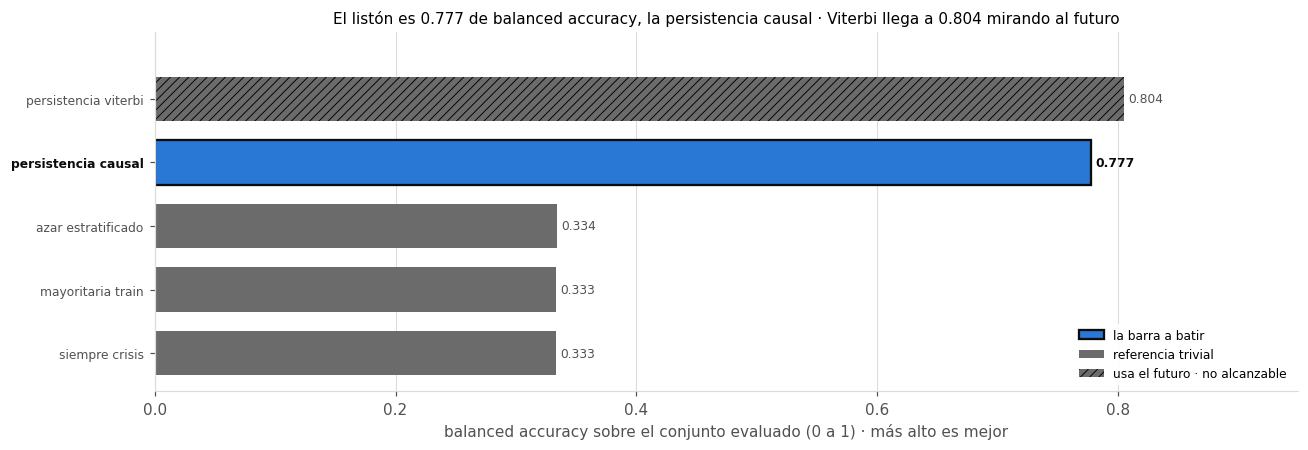

In [3]:
part = ventanas.cargar_procesado()
train, val, test = part.train, part.val, part.test
n_regimenes, forma_entrada = config.n_regimenes(), part.train.X.shape[1:]

etiquetador = regimenes.EtiquetadorRegimenes.cargar(src.DIR_PROCESADO / "etiquetador_regimenes.pkl")
canales = pd.read_parquet(src.DIR_PROCESADO / "canales.parquet")
hoy_causal = etiquetador.predict_causal(canales).reindex(test.fechas).to_numpy().astype(int)
hoy_viterbi = etiquetador.predict(canales).reindex(test.fechas).to_numpy().astype(int)

base = evaluacion.lineas_base(test.y_reg.astype(int), hoy_causal, hoy_viterbi,
                              train.y_reg.astype(int), n_regimenes)
barra = base.loc["persistencia_causal", downstream.METRICA_SELECCION]
lo, hi = evaluacion.banda_bloques(test.y_reg.astype(int), hoy_causal, "recall_crisis")

print(train, val, test, sep="\n")
print("Barra a batir ·", downstream.METRICA_SELECCION, round(barra, 4),
      "· recall de crisis {:.3f} con banda de bloques [{:.3f}, {:.3f}]".format(
          base.loc["persistencia_causal", "recall_crisis"], lo, hi))
print("Rachas de crisis ·", " · ".join(
    "{}: {} ventanas en {} rachas".format(n, int((c.y_reg == n_regimenes - 1).sum()),
                                          regimenes.tramos_contiguos(c.y_reg, n_regimenes - 1))
    for n, c in [("train", train), ("validación", val), ("test", test)]))

fig, eje = plt.subplots(figsize=(12, 4.2))
viz.lineas_base(base, downstream.METRICA_SELECCION, eje=eje)
viz.guardar(fig, "barra_a_batir")

base.round(4)

## 2 · Seis candidatas, y la parada que había que arreglar antes

El enunciado pide *buscar* una arquitectura con datos reales. Cada candidata mueve
**un solo eje** respecto a `cnn_base`: `lineal` quita la convolución entera y es el
control de si aporta algo; `cnn_pequena` y `cnn_ancha` mueven la capacidad;
`cnn_kernel7` el campo receptivo; `cnn_pool_global` la agregación temporal.

**Se puntúa sobre validación, nunca sobre test**, y con `balanced_accuracy`, no con
f1-macro: validación tiene un 22,0 % de crisis y test un 10,5 %, y bajo ese salto de
prevalencia el f1-macro invierte el orden del 8,1 % de los pares mientras que la
balanced accuracy es exactamente invariante.

**La parada temprana monitoriza esa misma métrica, no `val_loss`.** Los dos mínimos
no coinciden: la entropía cruzada de validación está dominada por el desajuste de
prevalencias entre train y validación, no por lo que el modelo aprende. La última
celda mide, sobre los 22 entrenamientos de este cuaderno, cuánto habría costado
parar por `val_loss`.

Gana lineal por 0.0039 sobre la segunda · dispersión entre semillas 0.0081 · 2 candidatas dentro de una desviación


,balanced_accuracy_media,balanced_accuracy_desv,f1_macro_media,recall_crisis_media,parametros_media,segundos_por_epoca_media
candidata,,,,,,
lineal,0.6956,0.0081,0.6504,0.5338,3603.0,0.3767
cnn_kernel7,0.6917,0.0122,0.6597,0.4842,271315.0,3.5700
cnn_base,0.6849,0.0391,0.6620,0.5180,167891.0,2.8200
cnn_ancha,0.6845,0.0092,0.6454,0.5405,533123.0,7.2500
cnn_pequena,0.6681,0.0168,0.6522,0.4257,69859.0,0.9233
cnn_pool_global,0.6617,0.0203,0.6542,0.4234,91091.0,2.6500


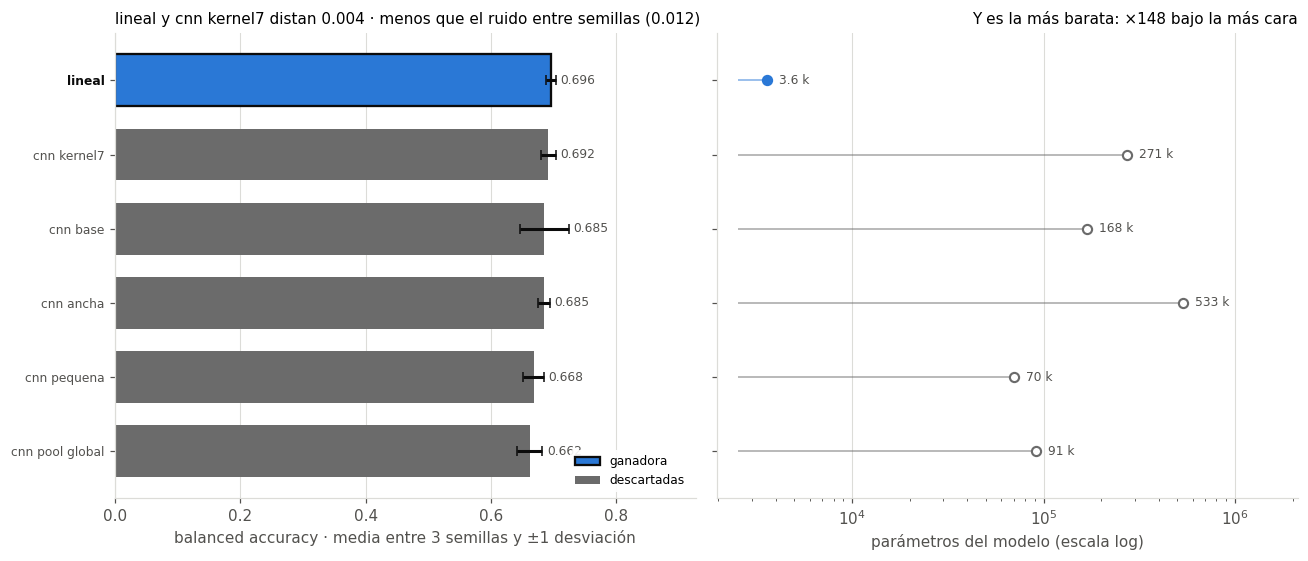

In [4]:
tabla = downstream.buscar(downstream.CANDIDATAS, train, val, "regimen",
                          n_clases=n_regimenes, semillas=(0, 1, 2))
resumen = downstream.resumen_busqueda(tabla)
clave, arquitectura = downstream.elegir(tabla)

orden = resumen.sort_values(downstream.METRICA_SELECCION + "_media", ascending=False)
margen = orden[downstream.METRICA_SELECCION + "_media"].iloc[0] - orden[downstream.METRICA_SELECCION + "_media"].iloc[1]
empatan = (orden[downstream.METRICA_SELECCION + "_media"]
           >= orden[downstream.METRICA_SELECCION + "_media"].iloc[0]
           - orden[downstream.METRICA_SELECCION + "_desv"].iloc[0]).sum()

print("Gana", clave, "por", round(margen, 4), "sobre la segunda · dispersión entre semillas",
      round(orden[downstream.METRICA_SELECCION + "_desv"].iloc[0], 4),
      "·", empatan, "candidatas dentro de una desviación")

fig, ejes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True)
viz.busqueda_arquitectura(resumen, downstream.METRICA_SELECCION + "_media",
                          downstream.METRICA_SELECCION + "_desv", ganadora=clave, eje=ejes)
viz.guardar(fig, "busqueda_arquitectura")

orden[[downstream.METRICA_SELECCION + "_media", downstream.METRICA_SELECCION + "_desv",
       "f1_macro_media", "recall_crisis_media", "parametros_media", "segundos_por_epoca_media"]].round(4)

## 3 · Gana la que no tiene convolución

`lineal` y `cnn_kernel7` caen dentro de una desviación entre semillas: no están
separadas por nada. Y la que encabeza es `lineal`, una multinomial sobre la ventana
aplanada con **3.603 parámetros**, frente a los 533.123 de `cnn_ancha`, a la que
gana además en tiempo por época por un factor de diecisiete.

Ese empate es el resultado, no un accidente: con 45 bloques independientes en train
(apartado 5) la convolución no tiene de dónde sacar ventaja. Se congela `lineal`
porque encabeza la métrica, gana el desempate por recall de crisis y es la más
barata, y porque D19 obliga a que el cuaderno 12 quepa en CPU.

A partir de aquí la arquitectura y su presupuesto quedan en
`models/downstream/arquitectura.json` con su huella: el cuaderno 12 los lee de ahí
en vez de heredar el valor por defecto del código.

CNN1D(filtros sin conv · kernel 3 · aplanado · sin densa · dropout 0.3) · huella df79bcab4ed6
Presupuesto(60 épocas · lote 256 · paciencia 12 · para por balanced_accuracy, val_mae en volatilidad)
Parámetros: 3603 · épocas efectivas: 60


f1_macro             0.4992
balanced_accuracy    0.5754
accuracy             0.5219
recall_crisis        0.5909
precision_crisis     0.1852
f1_crisis             0.282
soporte_crisis          110
conjunto               test
dtype: object

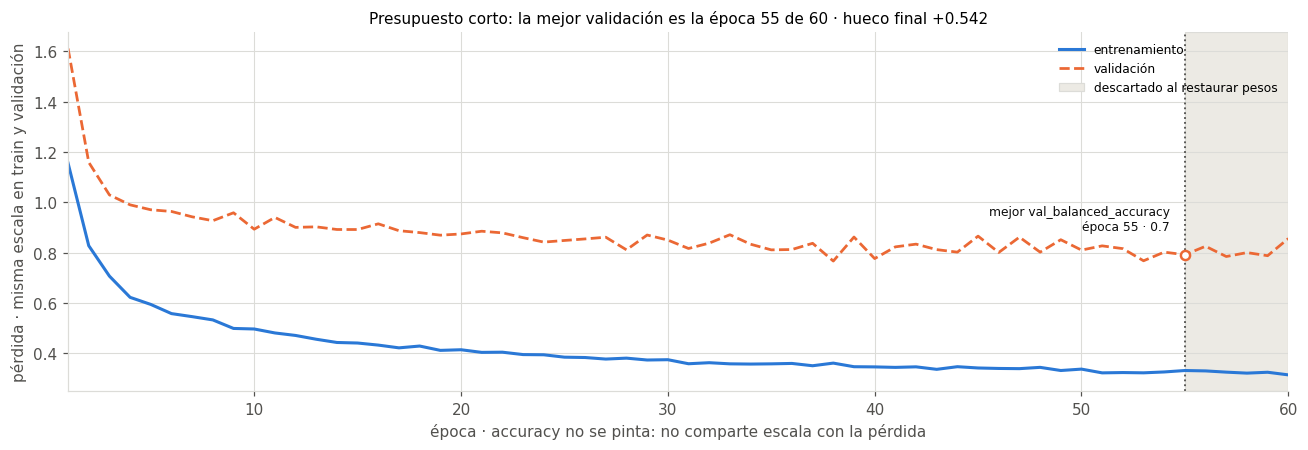

In [5]:
config.fijar_semillas()
modelo = downstream.construir("regimen", forma_entrada, n_clases=n_regimenes,
                              arquitectura=arquitectura)
historial = downstream.entrenar(modelo, train.X, train.y_reg, val.X, val.y_reg, tarea="regimen")
downstream.guardar_historial(historial, "baseline_regimen")
ruta_arq = downstream.congelar(arquitectura)

metricas = evaluacion.evaluar(modelo, test.X, test.y_reg, "regimen")
curva = pd.read_csv(src.DIR_HISTORIALES / "baseline_regimen.csv")

# La huella cubre arquitectura Y presupuesto: es la que valida `cargar_congelada`
# y la que escribe `arquitectura.json`. Imprimir solo la de la arquitectura daría
# dos huellas distintas para la misma congelación.
print(arquitectura, "· huella", downstream.huella(arquitectura, downstream.PRESUPUESTO))
print(downstream.PRESUPUESTO)
print("Parámetros:", modelo.count_params(), "· épocas efectivas:", len(curva))

fig, eje = plt.subplots(figsize=(12, 4.2))
viz.convergencia_downstream(curva, eje=eje)
viz.guardar(fig, "aprendizaje_baseline_regimen")

evaluacion.como_serie(metricas)

## 4 · El control bloqueante suspende

La regla se fijó antes de mirar: la arquitectura congelada tiene que batir a la
persistencia causal en balanced accuracy y en recall de crisis sobre test. **No lo
hace, y no por poco.**

La matriz de confusión dice dónde se rompe: el modelo dispara crisis muchas más
veces de las que hay, y casi todas las falsas vienen de la fila de transición. Su
precisión de crisis se hunde mientras el recall se queda a medias, que es el peor
de los dos mundos.

Esto no invalida el taller: **lo afila**. El experimento pregunta si los datos
sintéticos ayudan cuando los reales escasean, y el apartado 5 mide que aquí
escasean de verdad.

Control bloqueante: SUSPENDIDO · balanced accuracy 0.5754 frente a 0.7772
Crisis predichas: 351 · crisis reales: 110


,balanced_accuracy,f1_macro,accuracy,recall_crisis,precision_crisis
modelo congelado,0.575423,0.499237,0.521863,0.590909,0.185185
persistencia causal,0.777171,0.753572,0.771863,0.8,0.637681


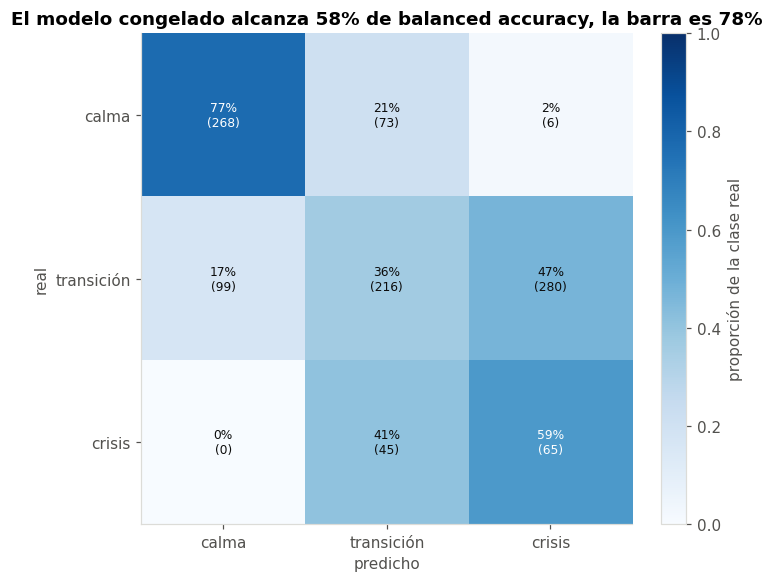

In [6]:
predicho = modelo.predict(test.X, verbose=0, batch_size=512).argmax(axis=1)
matriz = evaluacion.matriz_confusion(test.y_reg.astype(int), predicho, n_regimenes)

comparacion = pd.DataFrame({
    "modelo congelado": {k: v for k, v in metricas.items() if isinstance(v, float)},
    "persistencia causal": base.loc["persistencia_causal"].to_dict(),
}).T[["balanced_accuracy", "f1_macro", "accuracy", "recall_crisis", "precision_crisis"]]

veredicto = (metricas["balanced_accuracy"] >= base.loc["persistencia_causal", "balanced_accuracy"]
             and metricas["recall_crisis"] >= base.loc["persistencia_causal", "recall_crisis"])
print("Control bloqueante:", "SUPERADO" if veredicto else "SUSPENDIDO",
      "· balanced accuracy", round(metricas["balanced_accuracy"], 4),
      "frente a", round(base.loc["persistencia_causal", "balanced_accuracy"], 4))
print("Crisis predichas:", int((predicho == n_regimenes - 1).sum()),
      "· crisis reales:", int((test.y_reg == n_regimenes - 1).sum()))

fig, eje = plt.subplots(figsize=(6.6, 5.4))
viz.confusion(matriz, "El modelo congelado alcanza {:.0%} de balanced accuracy, la barra es {:.0%}".format(
    metricas["balanced_accuracy"], base.loc["persistencia_causal", "balanced_accuracy"]), eje=eje)
viz.guardar(fig, "confusion_baseline")

comparacion.round(4)

## 5 · No falta información, sobra formulación

Dos hechos medidos explican el suspenso, y el segundo es el que hay que decidir
antes de entrenar un generador.

**El downstream está famélico.** Las 3.696 ventanas de train son **45 bloques
disjuntos** de 81 sesiones, porque cada ventana comparte 59 de sus 60 días con la
vecina. Ese, y no 3.696, es el tamaño muestral honesto.

**La información sí está en la ventana; la tarea directa la desperdicia.** La misma
entrada, entrenada a predecir el régimen de **hoy**, acierta mucho más; y encadenar
esa predicción con la persistencia recupera buena parte del hueco, aunque no llega a
la barra. Aquí, además, la convolución **sí** paga: `cnn_ancha` supera a `lineal` por
más de doce puntos en la tarea auxiliar, justo lo contrario que en la directa. Que
el orden entre arquitecturas se invierta al cambiar el objetivo es la señal de que
el problema está en cómo se plantea la tarea.

Adoptar el encadenado toca D8 —los generadores tendrían que producir también el
régimen de hoy—, así que es una decisión del grupo y no se aplica aquí.

Bloques disjuntos · train: 45 · validación: 8 · test: 12
Las filas 'hoy' miden contra el régimen de HOY, no contra y_reg: dicen si la ventana contiene el estado, no si predicen el futuro.


,balanced_accuracy,f1_macro,accuracy,recall_crisis
hoy · lineal,0.681519,0.585774,0.607414,0.702899
encadenado · lineal,0.673793,0.548837,0.564639,0.790909
hoy · cnn_ancha,0.808454,0.8222,0.851711,0.630435
encadenado · cnn_ancha,0.719061,0.718123,0.749049,0.609091
directo · lineal,0.575423,0.499237,0.521863,0.590909
persistencia causal,0.777171,0.753572,0.771863,0.8


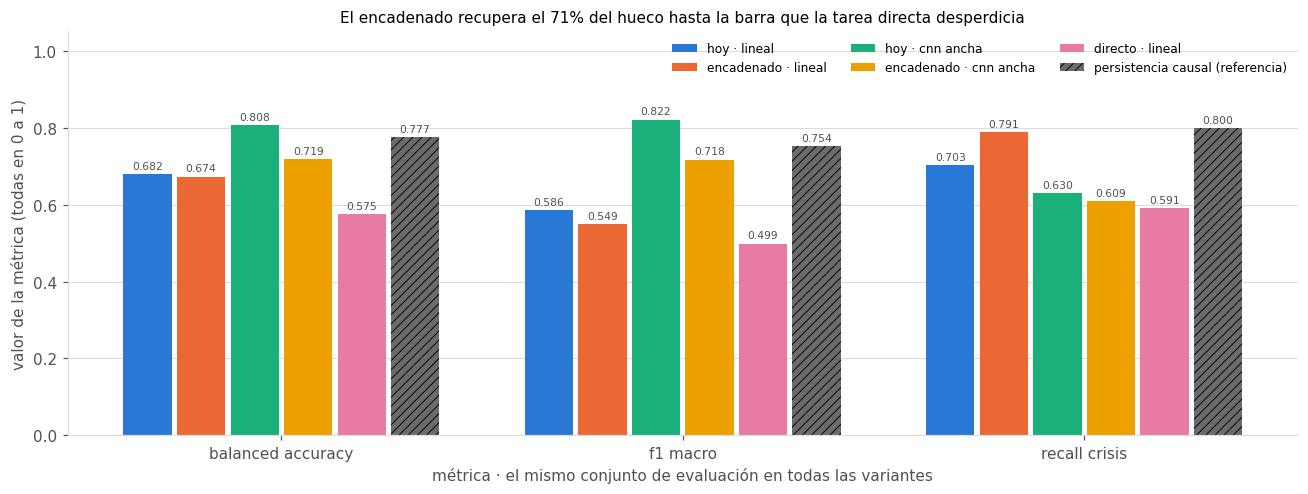

In [7]:
hoy = {n: etiquetador.predict_causal(canales).reindex(c.fechas).to_numpy().astype(int)
       for n, c in [("train", train), ("val", val), ("test", test)]}
filas = {}

for nombre in (clave, "cnn_ancha"):
    config.fijar_semillas()
    auxiliar = downstream.construir("regimen", forma_entrada, n_clases=n_regimenes,
                                    arquitectura=downstream.CANDIDATAS[nombre])
    h = downstream.entrenar(auxiliar, train.X, hoy["train"], val.X, hoy["val"], tarea="regimen")
    downstream.guardar_historial(h, "auxiliar_regimen_hoy__" + nombre)
    p = auxiliar.predict(test.X, verbose=0, batch_size=512).argmax(axis=1)
    filas["hoy · " + nombre] = evaluacion.metricas_regimen(hoy["test"], p, n_regimenes)
    filas["encadenado · " + nombre] = evaluacion.linea_base_persistencia(
        test.y_reg.astype(int), p, n_regimenes)

filas["directo · " + clave] = {k: v for k, v in metricas.items() if isinstance(v, float)}
filas["persistencia causal"] = base.loc["persistencia_causal"].to_dict()
informacion = pd.DataFrame(filas).T

bloques = {n: len(c) // (config.ventanas().pasado + config.ventanas().horizonte)
           for n, c in [("train", train), ("validación", val), ("test", test)]}
directo = informacion.loc["directo · " + clave, "balanced_accuracy"]
mejor_enc = informacion.filter(like="encadenado", axis=0)["balanced_accuracy"].max()
recuperado = (mejor_enc - directo) / (barra - directo)

print("Bloques disjuntos ·", " · ".join(f"{n}: {b}" for n, b in bloques.items()))
print("Las filas 'hoy' miden contra el régimen de HOY, no contra y_reg: dicen si la",
      "ventana contiene el estado, no si predicen el futuro.")

fig, eje = plt.subplots(figsize=(12, 4.6))
viz.comparativa_metricas(
    informacion, ["balanced_accuracy", "f1_macro", "recall_crisis"],
    titulo="El encadenado recupera el {:.0%} del hueco hasta la barra que la tarea directa desperdicia".format(recuperado),
    eje=eje)
viz.guardar(fig, "informacion_disponible")

informacion[["balanced_accuracy", "f1_macro", "accuracy", "recall_crisis"]].round(4)

## 6 · Reponderar, la tarea de control y lo que cuesta el cuaderno 12

**Reponderar la pérdida** es la alternativa gratuita al desbalance (D15). Sube el
recall de crisis y hunde todo lo demás: es la vara contra la que se leerá cualquier
mejora que traigan los sintéticos, porque lo que consiga `class_weight` no lo
consiguen ellos.

**La tarea de volatilidad es el control experimental** (D2): misma troncal, sin
desbalance. Aquí sí hay margen sobre su línea base trivial, y esa asimetría entre
las dos tareas es informativa por sí sola.

**El coste del barrido** se calcula con lo medido aquí, no se estima: segundos por
época de la arquitectura congelada y épocas efectivas medias de la búsqueda.

Volatilidad · MAE 0.0462 frente a 0.0496 de la media de train · R2 0.1641
Parar por val_loss en vez de por la métrica que decide, sobre 22 entrenamientos: cuesta 1.8 puntos de media y hasta 6.6 en el peor caso
Barrido a 0.38 s/época y 51.0 épocas efectivas de la congelada:
             recetas  entrenamientos  horas
generadores                                
4                165             330    2.2
7                285             570    3.8


,sin pesos,con pesos,persistencia causal
f1_macro,0.4992,0.4639,0.753572
balanced_accuracy,0.5754,0.5557,0.777171
accuracy,0.5219,0.4677,0.771863
recall_crisis,0.5909,0.6727,0.8
precision_crisis,0.1852,0.1729,0.637681
f1_crisis,0.2820,0.2751,0.709677
soporte_crisis,NaN,NaN,110
usa_futuro,NaN,NaN,False


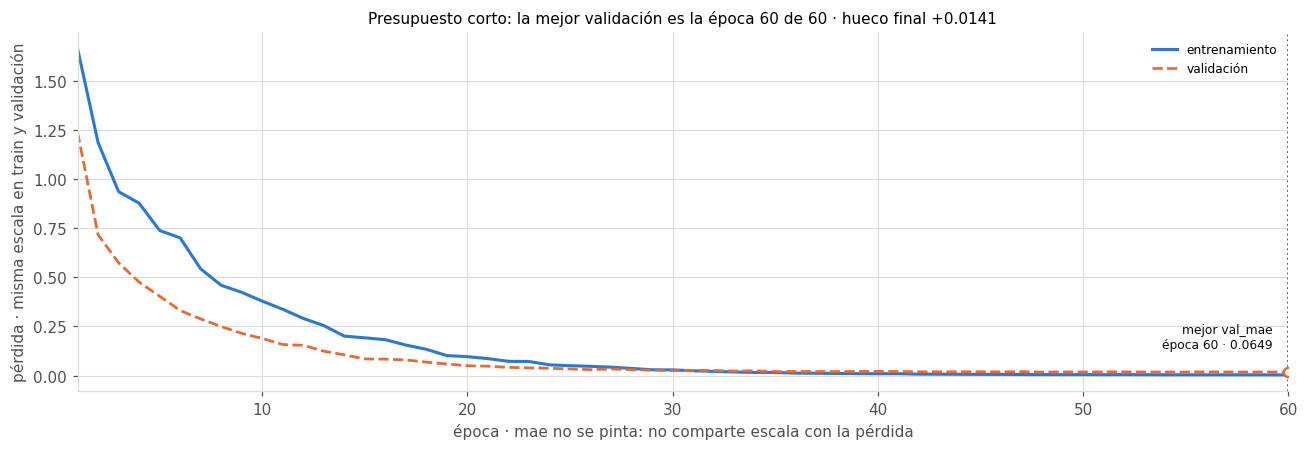

In [8]:
config.fijar_semillas()
con_pesos = downstream.construir("regimen", forma_entrada, n_clases=n_regimenes, arquitectura=arquitectura)
h_pesos = downstream.entrenar(con_pesos, train.X, train.y_reg, val.X, val.y_reg,
                              tarea="regimen", usar_pesos=True)
downstream.guardar_historial(h_pesos, "baseline_regimen_pesos")
metricas_pesos = evaluacion.evaluar(con_pesos, test.X, test.y_reg, "regimen")

config.fijar_semillas()
modelo_vol = downstream.construir("volatilidad", forma_entrada, n_clases=n_regimenes, arquitectura=arquitectura)
h_vol = downstream.entrenar(modelo_vol, train.X, train.y_vol, val.X, val.y_vol, tarea="volatilidad")
downstream.guardar_historial(h_vol, "baseline_volatilidad")
metricas_vol = evaluacion.evaluar(modelo_vol, test.X, test.y_vol, "volatilidad",
                                  referencia=float(train.y_vol.mean()))
base_vol = evaluacion.linea_base_volatilidad(train.y_vol, test.y_vol)

# Ambas magnitudes se toman de la ganadora, no de la media de las seis: el
# barrido entrena la congelada 570 veces y nada más. Mezclar sus segundos por
# época con las épocas medias del catálogo subestimaría el coste a la mitad.
seg_epoca = float(resumen.loc[clave, "segundos_por_epoca_media"])
epocas_medias = float(resumen.loc[clave, "epocas_media"])
rejillas = {n: mezclas.rejilla([f"g{i}" for i in range(n)]) for n in (4, 7)}
coste = pd.DataFrame([
    {"generadores": g, "recetas": len(r), "entrenamientos": 2 * len(r),
     "horas": sum((len(train) if x.n_reales is None else x.n_reales) * (1 + x.ratio) for x in r)
              * 2 * epocas_medias * seg_epoca / len(train) / 3600}
    for g, r in rejillas.items()]).set_index("generadores")

# Lo que habría costado parar por `val_loss` en vez de por la métrica que decide,
# sobre los entrenamientos de este cuaderno. Es la justificación del presupuesto.
curvas = sorted(src.DIR_HISTORIALES.glob("*.csv"))
perdido = []
for ruta in curvas:
    d = pd.read_csv(ruta)
    if "val_balanced_accuracy" not in d.columns:
        continue
    perdido.append(d["val_balanced_accuracy"].max()
                   - d["val_balanced_accuracy"].iloc[int(d["val_loss"].idxmin())])

print("Volatilidad · MAE", round(metricas_vol["mae"], 4), "frente a", round(base_vol["mae"], 4),
      "de la media de train · R2", round(metricas_vol["r2"], 4))
print("Parar por val_loss en vez de por la métrica que decide, sobre", len(perdido),
      "entrenamientos: cuesta", round(100 * np.mean(perdido), 1), "puntos de media y hasta",
      round(100 * max(perdido), 1), "en el peor caso")
print("Barrido a", round(seg_epoca, 2), "s/época y", round(epocas_medias, 1),
      "épocas efectivas de la congelada:")
print(coste.round(1).to_string())

fig, eje = plt.subplots(figsize=(12, 4.2))
viz.convergencia_downstream(pd.read_csv(src.DIR_HISTORIALES / "baseline_volatilidad.csv"), eje=eje)
viz.guardar(fig, "aprendizaje_baseline_volatilidad")

pd.DataFrame({"sin pesos": {k: v for k, v in metricas.items() if isinstance(v, float)},
              "con pesos": {k: v for k, v in metricas_pesos.items() if isinstance(v, float)},
              "persistencia causal": base.loc["persistencia_causal"].to_dict()}).round(4)

## Qué se lleva el resto del proyecto

- **La arquitectura congelada y su presupuesto**, en `models/downstream/arquitectura.json`
  con huella. El cuaderno 12 los carga con `downstream.cargar_congelada()`, y así un
  cambio en el código entre cuadernos se detecta en vez de contaminar 570 entrenamientos.
- **La barra y su banda.** La persistencia causal sobre test, y el aviso de que
  ninguna diferencia de recall de crisis menor de unos 20 puntos es distinguible del
  ruido con 3 rachas.
- **El control suspendido, con su causa medida.** 45 bloques independientes, y una
  formulación directa que desperdicia información que la ventana sí tiene.
- **El coste real del barrido**, calculado con la arquitectura que de verdad se va a
  entrenar, que decide si caben siete generadores o cuatro.

## Salidas generadas

In [9]:
from pathlib import Path

src.DIR_METRICAS.mkdir(parents=True, exist_ok=True)
src.DIR_MODELOS_DOWN.mkdir(parents=True, exist_ok=True)

modelo.save(src.DIR_MODELOS_DOWN / "baseline_regimen.keras")
modelo_vol.save(src.DIR_MODELOS_DOWN / "baseline_volatilidad.keras")
base.round(4).to_csv(src.DIR_METRICAS / "lineas_base.csv")
resumen.round(4).to_csv(src.DIR_METRICAS / "busqueda_arquitectura.csv")
# El argumento central del apartado 5 no puede vivir solo dentro de un PNG.
informacion.round(4).to_csv(src.DIR_METRICAS / "informacion_disponible.csv")
coste.round(2).to_csv(src.DIR_METRICAS / "coste_barrido.csv")
evaluacion.acumular([
    {"variante": "regimen", "tarea": "regimen", **metricas},
    {"variante": "regimen_pesos", "tarea": "regimen", **metricas_pesos},
    {"variante": "volatilidad", "tarea": "volatilidad", **metricas_vol}], "baseline")

salidas = [ruta_arq,
           src.DIR_MODELOS_DOWN / "baseline_regimen.keras",
           src.DIR_MODELOS_DOWN / "baseline_volatilidad.keras",
           src.DIR_METRICAS / "lineas_base.csv",
           src.DIR_METRICAS / "busqueda_arquitectura.csv",
           src.DIR_METRICAS / "informacion_disponible.csv",
           src.DIR_METRICAS / "coste_barrido.csv",
           src.DIR_METRICAS / "baseline.csv",
           src.DIR_FIGURAS / "barra_a_batir.png",
           src.DIR_FIGURAS / "busqueda_arquitectura.png",
           src.DIR_FIGURAS / "aprendizaje_baseline_regimen.png",
           src.DIR_FIGURAS / "confusion_baseline.png",
           src.DIR_FIGURAS / "informacion_disponible.png",
           src.DIR_FIGURAS / "aprendizaje_baseline_volatilidad.png"]

for ruta in salidas:
    ruta = Path(ruta)
    marca = "ok" if ruta.exists() else "--"
    print("[{}] {}".format(marca, ruta.relative_to(src.RAIZ)))

[ok] models\downstream\arquitectura.json
[ok] models\downstream\baseline_regimen.keras
[ok] models\downstream\baseline_volatilidad.keras
[ok] results\metricas\lineas_base.csv
[ok] results\metricas\busqueda_arquitectura.csv
[ok] results\metricas\informacion_disponible.csv
[ok] results\metricas\coste_barrido.csv
[ok] results\metricas\baseline.csv
[ok] results\figures\barra_a_batir.png
[ok] results\figures\busqueda_arquitectura.png
[ok] results\figures\aprendizaje_baseline_regimen.png
[ok] results\figures\confusion_baseline.png
[ok] results\figures\informacion_disponible.png
[ok] results\figures\aprendizaje_baseline_volatilidad.png
